In [1]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [2]:
import src.loader.load as load_module
reload(load_module)
load_data = load_module.load_data

In [3]:
data = load_data(r"./dummy_cell_tracks.csv", {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

In [4]:
import src.compute.stats as stats_module
reload(stats_module)
stats = stats_module.stats


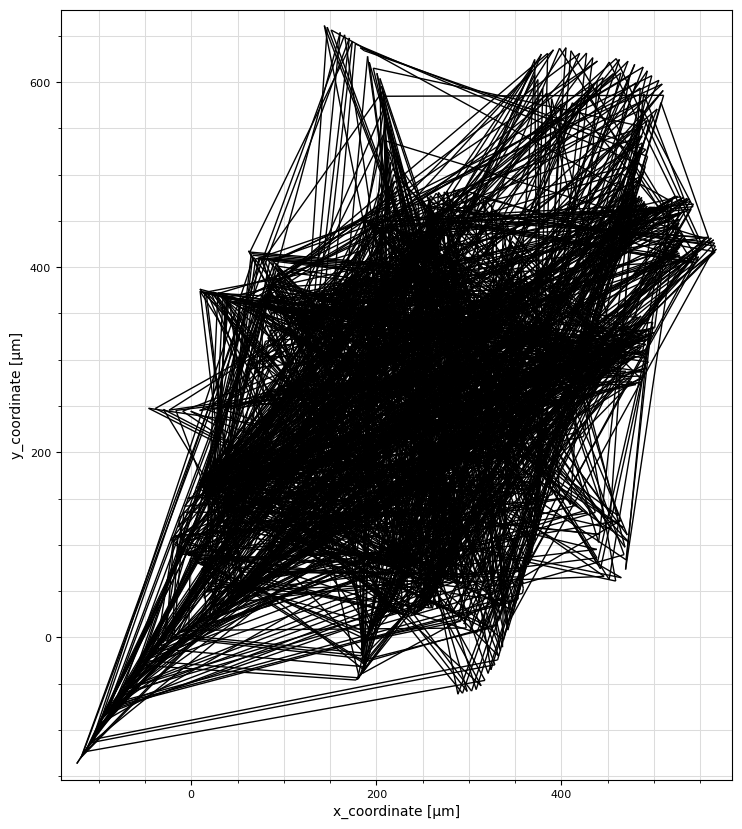

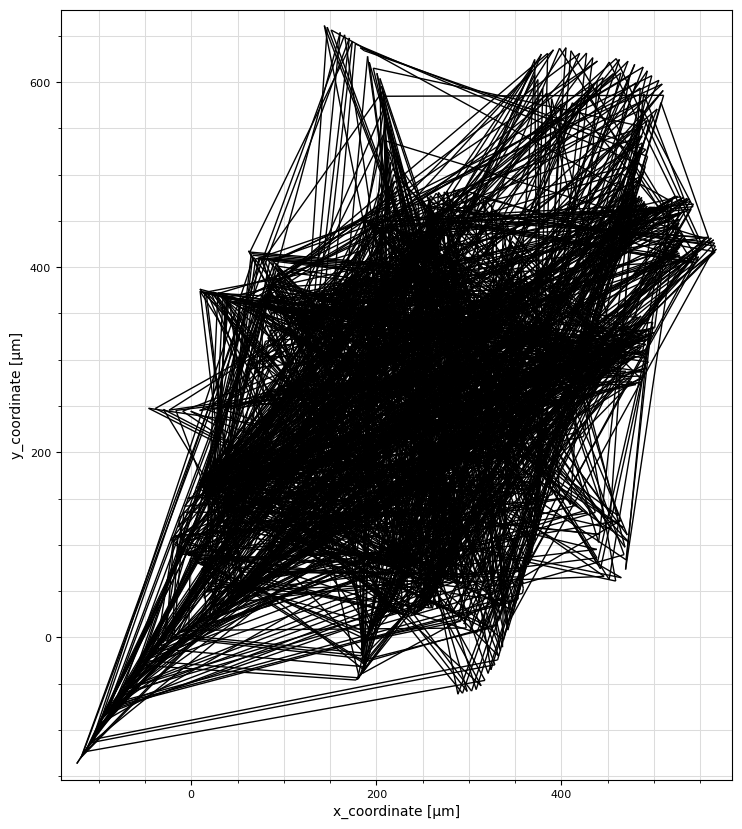

In [5]:
stats(data).plot_tracks()

In [6]:
A = stats.spots(data)

In [7]:
import src.plot.tracks.reconstruct as reconstruct_module
reload(reconstruct_module)
reconstruct_tracks = reconstruct_module.reconstruct


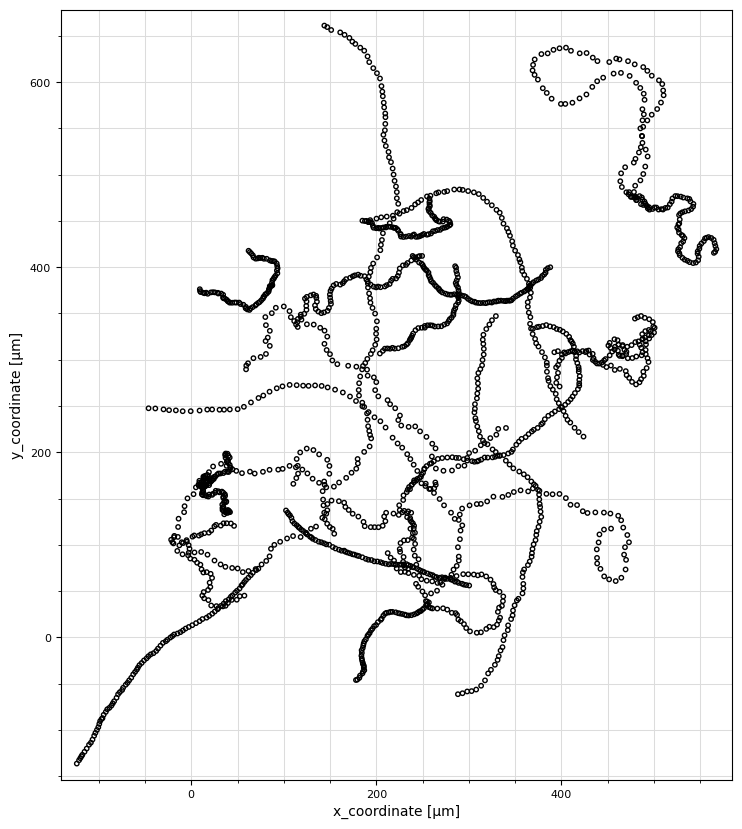

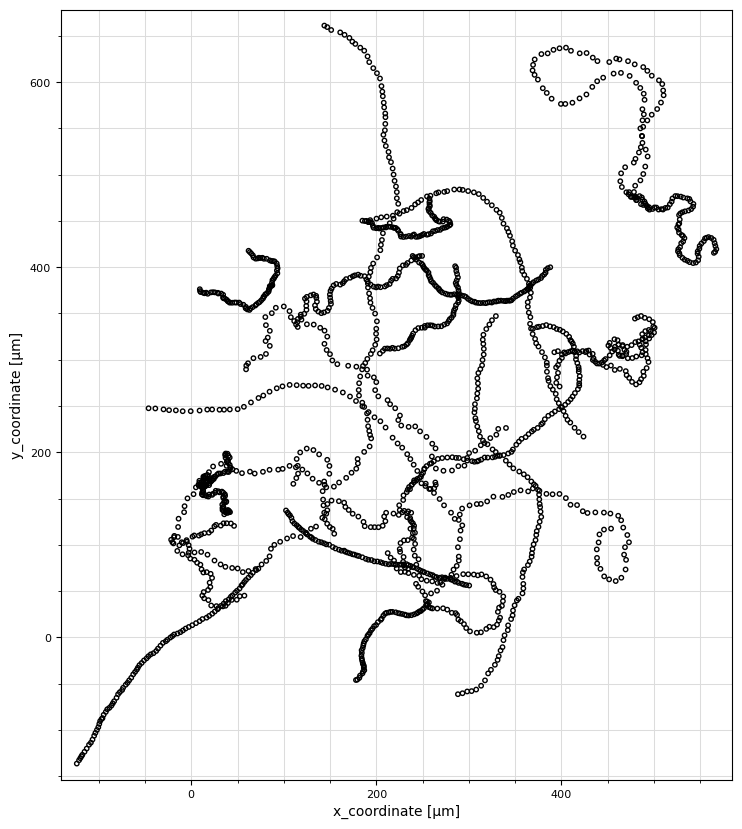

In [8]:
reconstruct_tracks(data)